
# **CAN'T SEE THE FOREST, FOR ALL THE TREES**

- **Project Overview**

    - The purpose of this project is to learn how to properly tune hyperparameters, as well as train and compare the performance of different models on a realistic problem..

    - The analysis focuses on tree-based models, specifically Decision Tree and Random Forest.

    - The dataset used in this project, along with its description, can be found [here](https://archive.ics.uci.edu/dataset/320/student+performance).The analysis is based on the file "student-por.csv".

- **Project Guidelines**

    - The notebook is structured to be executed from top to bottom. Each section follows a logical workflow to ensure reproducibility.

## **1. Imports and Setup**

In [1]:
# Import all necessary libraries here
# If additional libraries are needed, they should be added here for consistency

import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split  
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

## **2. Data Loading**

Load the dataset and import it into a pandas DataFrame.. 

Note: The dataset uses a semicolon delimiter (';') when loading with pd.read_csv.

---

In [3]:
# load the student-por dataset

student_df = pd.read_csv('data/student-por.csv', delimiter=';')

student_df.head()   # Displaying the first rows to understand the structure of the data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
student_df.shape              # Checking the shape of the dataset (rows, columns)

(649, 33)

In [5]:
student_df.info()             # Inspecting data types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [6]:
student_df.columns                # quick check all columns to understand available features

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

## **3. Exploratory Data Analysis (EDA)**




*We begin by exploring the dataset to understand the distribution of variables and their relationships with the target variable G3. The goal of this EDA is to identify patterns, trends, and potential factors influencing student performance.*

---

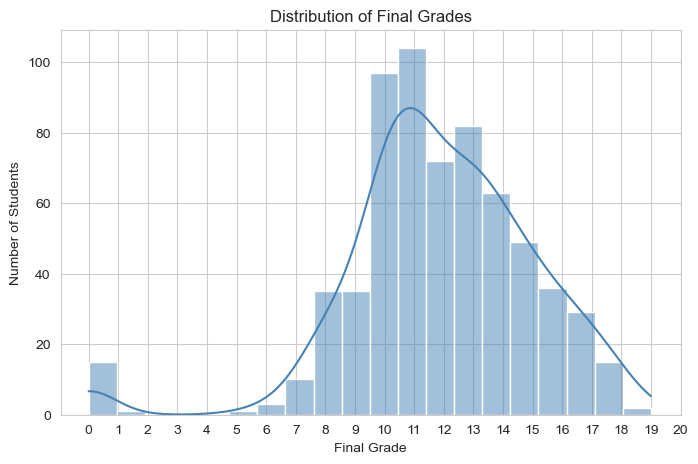

In [7]:
# Visualizing the distribution of the target variable final grade (G3)
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
sns.histplot(data=student_df, x="G3", bins=20, kde=True, color="steelblue")

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.xticks(range(0, 21))

plt.show()

*Most students have grades between 10 and 15, there are only a few very low or very high grades.*

*The average seems to be around 11–13, the distribution looks quite balanced. So a regression model should work well in this case.*

---

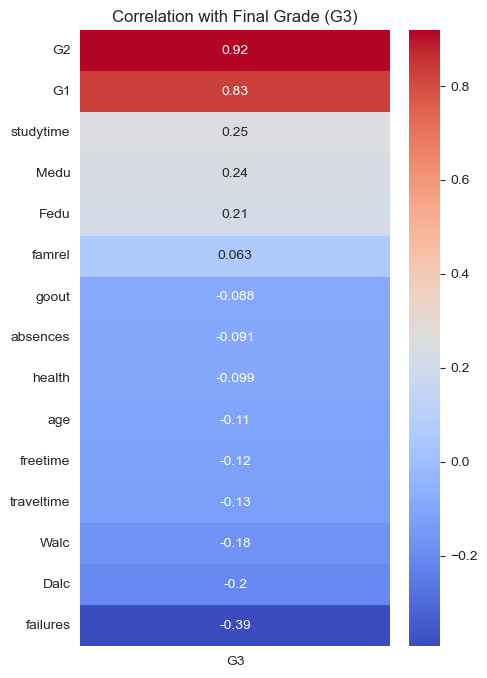

In [8]:
# Selecting only numerical columns for correlation analysis
# Correlation matrix helps identify relationships between variables

numeric_df = student_df.select_dtypes(include=["int64", "float64"])

# Get correlations with G3
corr_with_g3 = numeric_df.corr()["G3"].sort_values(ascending=False)              # Sorting correlations with respect to the target variable (G3)

# Remove G3 (because is 1.0)
corr_with_g3 = corr_with_g3.drop("G3")

# Plot
plt.figure(figsize=(5,8))
sns.heatmap(corr_with_g3.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Final Grade (G3)")
plt.show()

*G1 and G2 show a very strong correlation with G3, which is expected since they represent earlier grades. However these variables will not be used in the model later, as they would introduce data leakage.*

*Other variables show weaker but meaningful relationships. Study time has a positive correlation with the final grade, indicating that students who study more tend to perform better. Failures show a negative correlation, suggesting that students with past academic difficulties are more likely to have lower final grades, and absences also have a negative impact, meaning that missing classes may affect performance.*

---

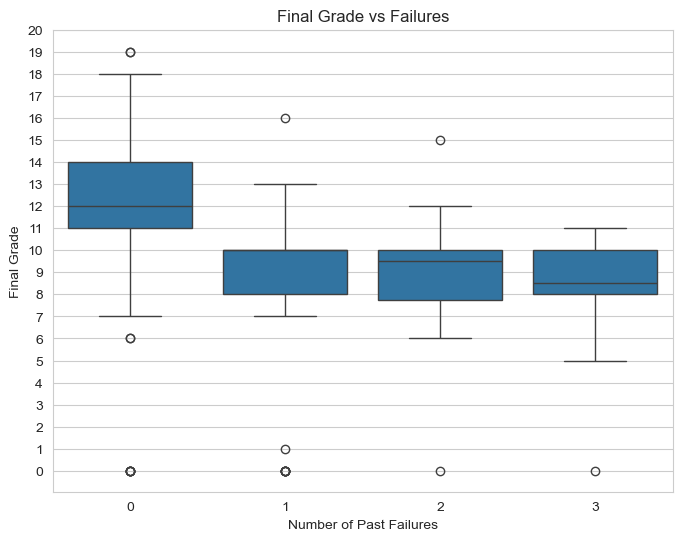

In [9]:
# Visualizing the relationship between past failures and final grade (G3)

plt.figure(figsize=(8,6))
sns.boxplot(data=student_df, x="failures", y="G3")           # Boxplot is useful to compare distributions across categories

plt.title("Final Grade vs Failures")
plt.xlabel("Number of Past Failures")
plt.ylabel("Final Grade")
plt.yticks(range(0, 21))

plt.show()

*Students with no past failures tend to have higher average grades. As the number of failures increases, the median grade decreases significantly.*

*There is still some overlap between the groups, meaning that not all students with failures perform poorly. This indicates a strong negative relationship, but not a perfect predictor.*

---

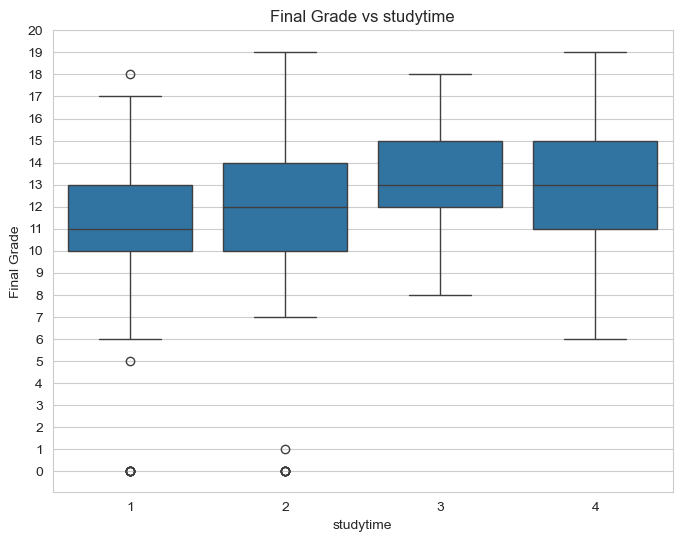

In [10]:
# Visualizing the relationship between study time and final grade (G3)

plt.figure(figsize=(8,6))
sns.boxplot(data=student_df, x='studytime', y="G3")                      # Boxplot allows comparison of grade distributions for different studytime levels

plt.title("Final Grade vs studytime")
plt.xlabel("studytime")
plt.ylabel("Final Grade")
plt.yticks(range(0, 21))

plt.show()

*Students who study more tend to have higher grades. There is a clear increase in G3 as studytime increases, although the difference is not extremely large.*

*The difference between groups is not very large, and there is significant overlap between them. This suggests that studytime has a positive but relatively weak effect on final grades.*

---

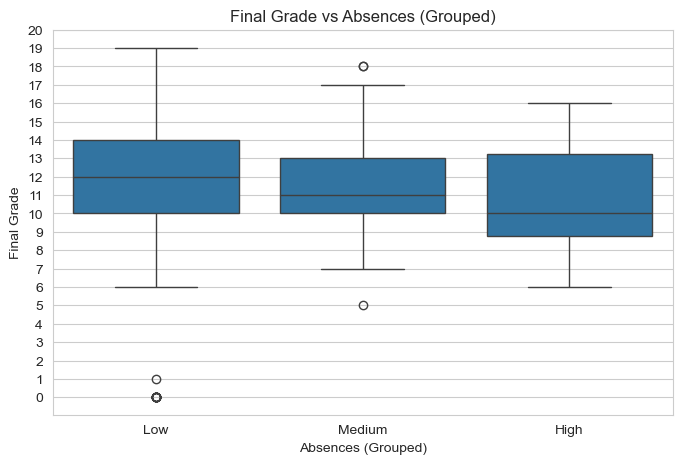

In [11]:
# Grouping absences into categories (Low, Medium, High)
# This simplifies the analysis and makes patterns easier to interpret

student_df["absences_group"] = pd.cut(
    student_df["absences"],  
    bins=[-1, 5, 20, 100],  
    labels=["Low", "Medium", "High"]
    )

# Visualizing how grouped absences relate to final grades (G3)
plt.figure(figsize=(8,5))
sns.boxplot(data=student_df, x="absences_group", y="G3")
plt.title("Final Grade vs Absences (Grouped)")
plt.xlabel("Absences (Grouped)")
plt.ylabel("Final Grade")
plt.yticks(range(0, 21))

plt.show()

*To better understand the relationship, absences were grouped into three categories: Low, Medium, and High.*

*Students with fewer absences tend to have slightly higher grades. When absences increase the grades tend to decrease, this means the relationship is not very strong.*

---

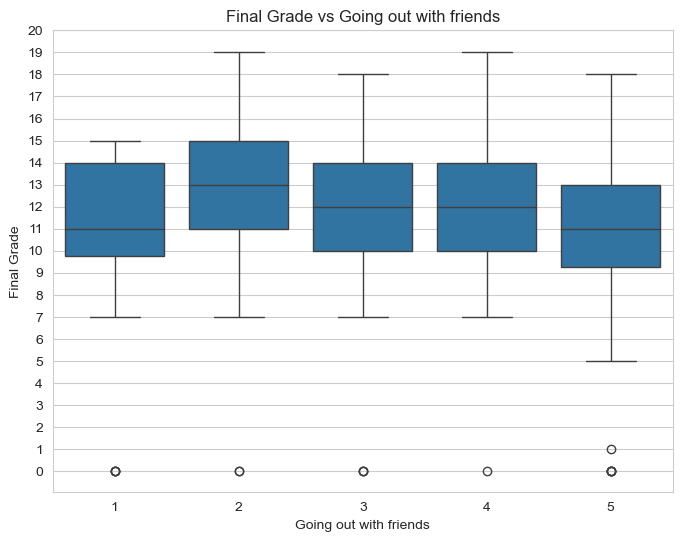

In [12]:
# Visualizing the relationship between social activity (going out) and final grades
# This helps evaluate whether lifestyle factors influence academic performance

plt.figure(figsize=(8,6))
sns.boxplot(data=student_df, x='goout', y="G3")

plt.title("Final Grade vs Going out with friends")
plt.xlabel("Going out with friends")
plt.ylabel("Final Grade")
plt.yticks(range(0, 21))

plt.show()

*There does not seem to be a strong relationship between going out with friends and final grades. The distribution of grades is quite similar across all groups.*


*This suggests that social activity alone is not a strong predictor of academic performance.*

---

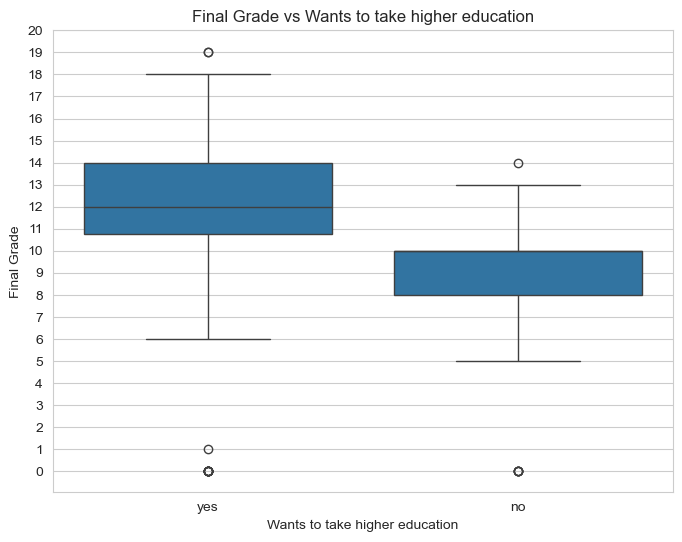

In [13]:
# Visualizing the relationship between students intention to pursue higher education and final grades
# This can reflect motivation and long-term academic goals

plt.figure(figsize=(8,6))
sns.boxplot(data=student_df, x='higher', y="G3")

plt.title("Final Grade vs Wants to take higher education")
plt.xlabel("Wants to take higher education")
plt.ylabel("Final Grade")
plt.yticks(range(0, 21))

plt.show()

*Students who want to pursue higher education tend to have higher final grades. This suggests that motivation and future goals may have a positive impact on academic performance.*

---

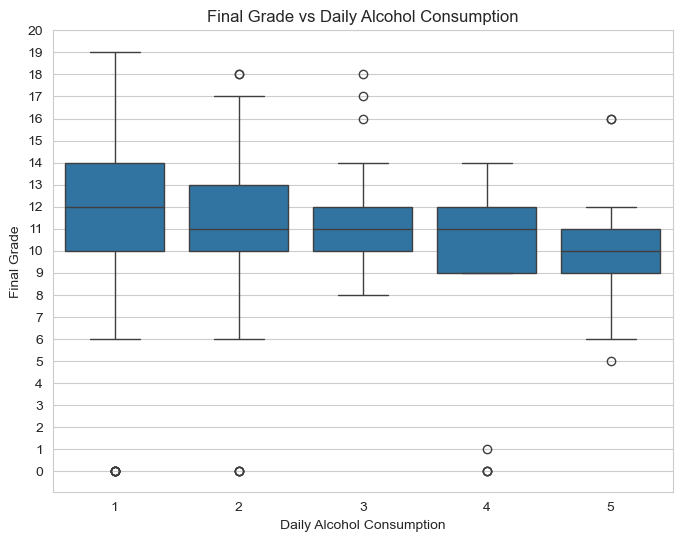

In [14]:
# Visualizing the relationship between daily alcohol consumption and final grades
# This helps evaluate whether lifestyle habits affect academic performance

plt.figure(figsize=(8,6))
sns.boxplot(data=student_df, x='Dalc', y="G3")

plt.title("Final Grade vs Daily Alcohol Consumption")
plt.xlabel("Daily Alcohol Consumption")
plt.ylabel("Final Grade")
plt.yticks(range(0, 21))

plt.show()

*This suggests that alcohol consumption may have some impact, but it is less important compared to variables like failures or studytime.*

---

## **4. Data Preprocessing & Feature Engineering**

**According to the exploratory data analysis (EDA), the features can be grouped into different categories:**

- Academic features: Study time and failures, appear to be the most important.

- Behavioral features: Social outings and free time, can influence performance, although their effect appears to be minor.

- Family-related features: Socioeconomic status (Pstatus), family relationships (famrel), and supportive family (famsup), could be relevant, that describe the student's environment. (Even if their effect is not directly visible in simple plots.)

- Motivational features: Motivation, appear to be important, since they are associated with better grades.

- Lifestyle features: Absences, health, and commuting time, can also indirectly affect performance.

- Risk features: Alcohol consumption (Dalc, Walc), may have some negative impact, although not a very strong one.

---

In [15]:
student_df.isnull().sum()  # Checking for missing values in the dataset

school            0
sex               0
age               0
address           0
famsize           0
Pstatus           0
Medu              0
Fedu              0
Mjob              0
Fjob              0
reason            0
guardian          0
traveltime        0
studytime         0
failures          0
schoolsup         0
famsup            0
paid              0
activities        0
nursery           0
higher            0
internet          0
romantic          0
famrel            0
freetime          0
goout             0
Dalc              0
Walc              0
health            0
absences          0
G1                0
G2                0
G3                0
absences_group    0
dtype: int64

*The dataset contains no missing values, so no imputation or data filling is required.*

---

In [16]:
# Inspecting high absence values to check for potential outliers

high_absences = student_df[student_df["absences"] > 20]

high_absences[["absences", "G1", "G2", "G3"]]

,absences,G1,G2,G3
150,24,9,8,9
155,22,9,7,6
197,32,14,13,14
212,30,14,15,16
217,21,13,13,13
256,26,7,8,8
325,22,11,11,10
413,21,9,10,10


*Most variables in the dataset are categorical or have small ranges, so they do not contain clear outliers.*

*The main exception is absences, which has a wider range and some extreme values. However, these values appear to be valid observations rather than errors.*

*Some variables, such as goout or alcohol consumption, show more variability and can be considered noisy rather than containing outliers.*

---

### **ONE HOT ENCOING**

In [17]:
# Defining categorical columns to be encoded

categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'] 

# Applying one-hot encoding to convert categorical variables into numeric format
student_df_encoded = pd.get_dummies(student_df, columns=categorical_cols, dtype=int, drop_first=True)  # drop_first=True is used to avoid multicollinearity

student_df_encoded.head()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,0,4,3,2,2,...,1,0,1,0,0,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,0,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,0,0,1,1,0,0


In [18]:
# Removing 'absences_group' since it was created only for visualization
# The column was created only for visualization, we removed it to avoid duplicated information and keep the original 'absences'

student_df_encoded = student_df_encoded.drop(columns=["absences_group"])

In [19]:
student_df_encoded.shape

(649, 42)

*Categorical variables were transformed using one-hot encoding in order to convert them into a numerical format suitable for machine learning models.*

*The parameter drop_first=True was used to avoid multicollinearity. After encoding, the dataset increased in the number of features, but this is expected and does not represent a problem given the size of the dataset.*

---

## **5. Feature Selection & Target Definition**

In [20]:
# Removing G1 and G2 to prevent data leakage
student_df_encoded = student_df_encoded.drop(columns=["G1", "G2"])

# Define features and target
X = student_df_encoded.drop(columns=["G3"])
y = student_df_encoded["G3"]

# Saving feature column names for later use.
feature_column_names = X.columns

*G1 and G2 were removed because they are previous grades and strongly related to final grades (G3). Including them would introduce data leakage, since the model would learn from information that would not be available in a real prediction scenario.*

---

## **6. Model Training & Initial Evaluation**

In [21]:
# Split data into training and testing sets, 80% for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shapes
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(519, 39) (130, 39)
(519,) (130,)


In [22]:
# Create Random Forest model
model = RandomForestRegressor(
                                n_estimators=100,     # number of trees
                                 max_depth=None,      # max depth of each tree
                                random_state=42) 

model.fit(X_train, y_train)  # Training a Random Forest Regressor model

# Make predictions for training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluating model performance using MAE and RMSE
# Training metrics
train_mae = round(mean_absolute_error(y_train, y_train_pred), 2)
train_rmse = round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2)

# Test metrics
test_mae = round(mean_absolute_error(y_test, y_test_pred), 2)
test_rmse = round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2)

# Print results
print("===== TRAIN RESULTS =====")
print("TRAIN MAE:", train_mae)
print("TRAIN RMSE:", train_rmse)
print()
print("===== TEST RESULTS =====")
print("TEST MAE:", test_mae)
print("TEST RMSE:", test_rmse)

===== TRAIN RESULTS =====
TRAIN MAE: 0.74
TRAIN RMSE: 1.02

===== TEST RESULTS =====
TEST MAE: 2.06
TEST RMSE: 2.84


**The model performs very well on the training data, with low MAE and RMSE values. While the performance on the test data is worse, indicating that the model is slightly overfitting.**

- This means the model has learned the training data very well but does not generalize equally well to unseen data.

- The test error is still reasonable, with an average prediction error of around 2 grade points, which can be that the model has acceptable predictive performance.

---

### **Feature Importance Analysis**

Run the code below to examine the relative importance of each feature in the trained model. A higher value indicates a more important feature.


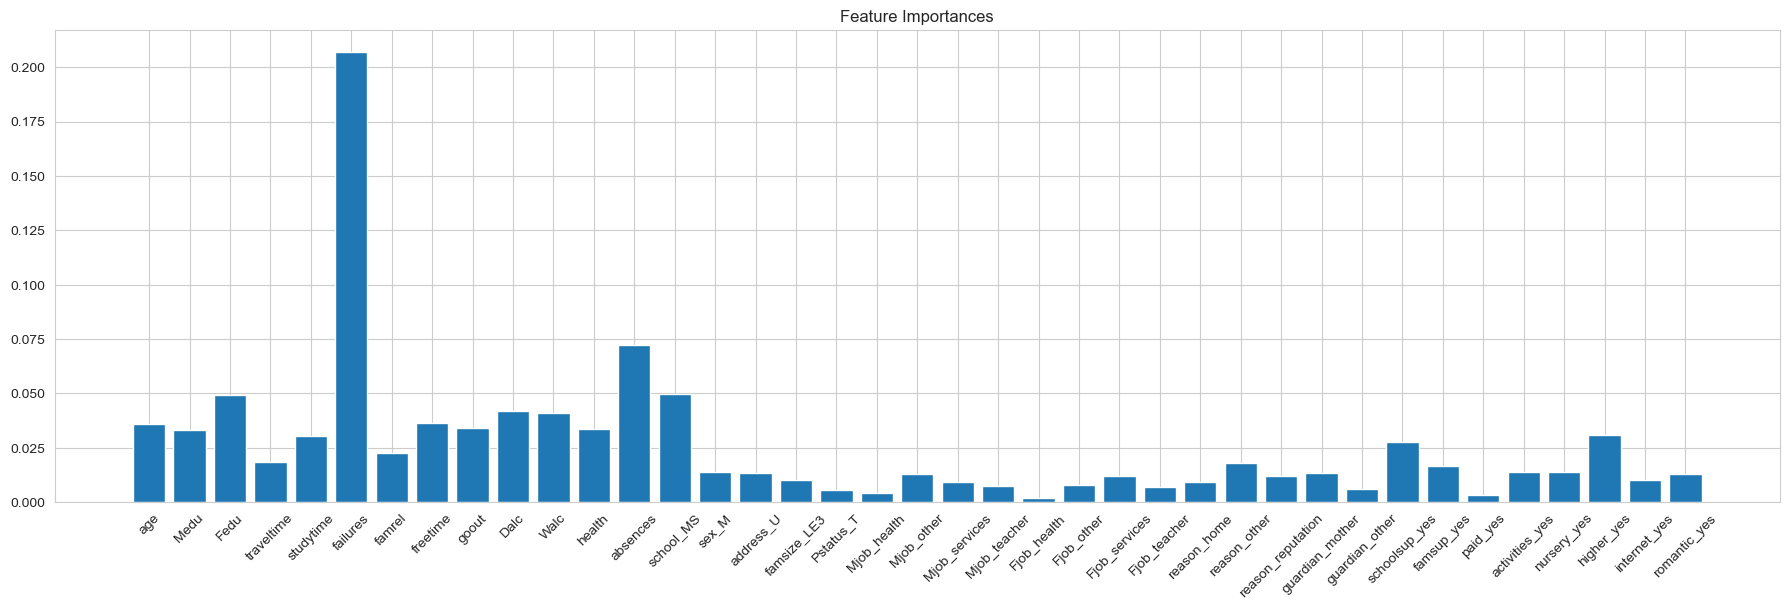

In [23]:
# Plotting feature importances from the trained Random Forest model

plt.figure(figsize=(18,6))                                                  # Increasing figure size to improve visualization clarity
plt.bar(feature_column_names, model.feature_importances_);
plt.xticks(rotation=45);                                                    # Rotating x-axis labels for better readability
plt.tight_layout() 
plt.title("Feature Importances")
plt.show()

***The feature importance results are consistent with the findings from the EDA.*** 

*Failures appears as one of the most important variables, confirming its strong negative relationship with final grades. Studytime and absences also show moderate importance, which aligns with previous observations.*

*Most other variables have relatively low importance, suggesting that they contribute less individually to the model’s predictions, they may still play a role when combined with other features.*

---

## **7. Hyperparameter Tuning with Grid Search**

This section performs hyperparameter tuning using GridSearchCV with cross-validation to evaluate all specified parameter combinations.

The goal is to identify the best-performing Random Forest configuration based on Mean Absolute Error (MAE).

In [ ]:
# Define a parameter grid for hyperparameter tuning

param_grid = {
    'max_depth': [2, 4, 6],                 # Maximum depth of each tree
    'n_estimators': [2, 4, 6, 8, 10]        # Number of trees in the forest
}

# Initialize the base model
rf = RandomForestRegressor()

# Define the evaluation metric. We use MAE (Mean Absolute Error) as the scoring metric
# Since lower MAE is better, we set greater_is_better=False
score = make_scorer(mean_absolute_error, greater_is_better=False)  
                                                                     
# Define the GridSearchCV object
grid_search = GridSearchCV(estimator = rf,                # Base model
                           param_grid = param_grid,       # Hyperparameter combinations to evaluate
                           cv = 3,                        # 3-fold cross-validation
                           n_jobs = -1,                   #Use all available CPU cores for faster computation
                           verbose = 2,                   # Display training progressr
                           scoring=score)                 # Evaluation metric

# Run grid search over all parameter combinations
# Note: We use the full dataset (X, y), as cross-validation
# internally handles the data splitting
grid_search.fit(X, y)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [2, 4, ...], 'n_estimators': [2, 4, ...]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,4


---

## **8. Grid Search Results**

This section reviews the key information stored during the GridSearch process, including the best model, selected hyperparameters, and cross-validation results.

In [25]:
cv_results = grid_search.cv_results_                            # Get all results from GridSearch (cross-validation results)
cv_results.keys()                                               # This helps understand what information is stored (scores, parameters, etc.)                                             

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

---

## **9. Hyperparameter Tuning Analysis**

This section analyzes the performance of different hyperparameter combinations evaluated during the GridSearch process, identifying the best and worst configurations.

In [ ]:
results_rf = pd.DataFrame(grid_search.cv_results_)                                                             # Convert GridSearch results into a DataFrame
results_rf = results_rf.sort_values(by="mean_test_score").reset_index(drop=True)                               # Sort results by score
results_rf["MAE"] = -results_rf["mean_test_score"].round(2)                                                    # Convert negative score to real MAE (positive)                                       # Round scores 
results_rf = results_rf[["param_max_depth", "param_n_estimators", "MAE", "rank_test_score"]]                   # Select only the most relevant columns for interpretation

results_rf.iloc[[0, -1]]                 # Keep only the worst and best models

,param_max_depth,param_n_estimators,MAE,rank_test_score
0,6,2,2.36,15
14,6,4,2.18,1


- The best model uses max_depth=6 and n_estimators=10, with mean score = ~ 2.18

- The worst model uses max_depth=4 and n_estimators=2, with mean score = ~ 2.36

*This means that more trees and deeper models perform better. The difference between the best and worst score is small, but still shows the impact of hyperparameter tuning.*

---

## **10. Error Analysis**

This section analyzes the model's prediction errors to better understand where it performs well and where it fails. 

In [27]:
# Create analysis DataFrame combining features, actual values and predictions

analysis_df = pd.DataFrame(X_test, columns=feature_column_names)

# Add actual and predicted values
analysis_df["Actual"] = y_test
analysis_df["Predicted"] = y_test_pred

analysis_df["Error"] = np.abs(y_test - y_test_pred)                                          # Calculate absolute error
analysis_df = analysis_df.sort_values(by="Error", ascending=False).reset_index(drop=True)    # Sort by error (descending) to see where the model fails the most

analysis_df.head(10)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,Actual,Predicted,Error
0,18,4,2,1,2,0,5,3,1,1,...,0,0,1,1,1,1,1,0,13.11,13.11
1,18,4,4,1,2,0,3,2,4,1,...,0,0,1,0,1,1,0,19,11.74,7.26
2,17,4,2,2,2,0,4,3,3,2,...,1,0,0,0,1,1,0,18,11.14,6.86
3,18,1,1,1,1,2,2,3,5,2,...,0,0,0,1,0,1,1,0,6.59,6.59
4,18,1,1,2,3,0,5,3,2,1,...,0,0,0,1,1,1,0,18,11.71,6.29
5,16,4,4,1,2,0,4,3,4,1,...,1,0,0,1,1,1,1,8,13.80,5.80
6,17,4,4,2,1,1,4,2,4,2,...,1,0,0,1,1,1,0,16,10.28,5.72
7,18,3,1,1,2,0,4,3,4,1,...,1,0,0,1,1,1,0,16,10.31,5.69
8,17,4,2,2,4,0,4,2,3,3,...,0,0,0,1,1,1,1,18,12.59,5.41
9,16,2,1,1,2,0,3,2,2,1,...,0,0,0,1,1,1,1,16,10.61,5.39


In [28]:
# General error statistics

analysis_df["Error"].describe()

count    130.000000
mean       2.061846
std        1.953346
min        0.020000
25%        0.632500
50%        1.425000
75%        2.837500
max       13.110000
Name: Error, dtype: float64

*The average error is around 2 points, which matches the MAE obtained earlier.*

*The maximum error is much higher (~13), indicating that the model performs poorly in some extreme cases.*

In [29]:
# group the data by number of failures and calculated the average error for each group

failures_error = analysis_df.groupby("failures")["Error"].mean().sort_values()
print("Error by failures:")
print(failures_error)

Error by failures:
failures
3    1.377500
1    1.743077
0    2.082857
2    6.590000
Name: Error, dtype: float64


*Students with 2 past failures have a much higher prediction error compared to other groups. This suggests that the model struggles to predict performance for this group, possibly because they behave differently or are underrepresented in the dataset.*

In [30]:
# group the data by study time and calculated the mean error of the model for each level

studytime_error = analysis_df.groupby("studytime")["Error"].mean().sort_values()
print("Error by studytime:")
print(studytime_error)

Error by studytime:
studytime
1    1.935789
2    2.063793
3    2.136667
4    2.350000
Name: Error, dtype: float64


*Students who study more seem to have slightly higher prediction errors. This suggests that studytime alone is not enough to explain performance and other factors may be involved.*

In [31]:
# Create groups based on number of absences. This helps to analyze how the model error behaves for different absence levels

analysis_df["absences_group"] = pd.cut(
    analysis_df["absences"],
    bins=[-1, 5, 20, 100],                   # define ranges for grouping
    labels=["Low", "Medium", "High"]         # define name label each grouping
)

# Calculate and sort the average error for each group. 
analysis_df.groupby("absences_group")["Error"].mean().sort_values()

absences_group
Medium    1.570968
Low       2.179796
High      5.720000
Name: Error, dtype: float64

*The model works better for students with a medium number of absences. For students with many absences, the error is much higher, so the model does not predict well in these cases.*

In [32]:
# group the data by going out and calculated the mean error of the model for each level

goout_error = analysis_df.groupby("goout")["Error"].mean().sort_values()
print("Error by Going out with friends:")
print(goout_error)

Error by Going out with friends:
goout
3    1.677500
5    1.916154
2    2.260000
4    2.277097
1    2.514000
Name: Error, dtype: float64


*The model works better for students with a medium level of going out. For very low or very high values, the error is higher, so the model does not predict as well.*

- ***Error analysis was focused on the most relevant features identified during EDA, rather than all variables, to keep the analysis meaningful and interpretable.***

- ***The average error is around 2 points, so the model works reasonably well overall.***

- ***The error analysis shows that the model performs worse for some groups, especially in extreme cases like students with many absences or specific failure levels. This pattern is consistent across different features, where the model performs worse on extreme values and better on more common cases. This means the score is acceptable, but the model is not equally reliable for all students.***

---

## **11. Extended Hyperparameter Tuning**

This section extends the hyperparameter search by testing additional Random Forest parameters beyond max_depth and n_estimators.

The objective is to explore whether a broader search space can improve model performance and provide a better configuration than the initial GridSearch.

In [ ]:
param_grid = {
    'n_estimators': [50, 100],        # number of trees
    'max_depth': [5, 10],             # maximum depth of each tree
    'min_samples_split': [2, 5],      # minimum samples required to split a node
    'min_samples_leaf': [1, 2],       # minimum samples required in a leaf node
    'max_features': ['sqrt'],         # minimum samples required to split a node
    'bootstrap': [True]               # number of features used for each split (reduced combinations)
}

# Create Random Forest model
rf = RandomForestRegressor()

# Define metrics to measure performance
score = make_scorer(mean_absolute_error, greater_is_better=False)   # Define evaluation metric (MAE)
                                                                    
# Use GridSearch to test different hyperparameter combinations
# and evaluate performance using cross-validation

grid_search_rf = GridSearchCV(estimator = rf,             # ange basmodell
                           param_grid = param_grid, 
                           cv = 3,                        # 3-fold cross-validation
                           n_jobs = -1,                   # use all possible processes for faster training
                           verbose = 2,                   # read the documentation to see what this means
                           scoring=score) 

# Perform GridSearch over all combinations of hyperparameters
grid_search_rf.fit(X, y)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,RandomForestRegressor()
,param_grid,"{'bootstrap': [True], 'max_depth': [5, 10], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], ...}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [34]:
cv_results_rf = grid_search_rf.cv_results_                           # Get all results from GridSearch (cross-validation results)
cv_results_rf.keys()                                                 # This helps understand what information is stored (scores, parameters, etc.)

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_bootstrap', 'param_max_depth', 'param_max_features', 'param_min_samples_leaf', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [ ]:
results = pd.DataFrame(grid_search_rf.cv_results_)                                          # Convert GridSearch results into a DataFrame
results = results.sort_values(by="mean_test_score").reset_index(drop=True)                  # Sort results by score
results["MAE"] = -results["mean_test_score"].round(2)                                       # Convert negative score to real MAE (positive)     
results = results[["param_max_depth", "param_n_estimators", "MAE", "rank_test_score"]]      # Select only the most relevant columns for interpretation

results.iloc[[0, -1]]              # Keep only the worst and best models

,param_max_depth,param_n_estimators,MAE,rank_test_score
0,10,50,2.14,16
15,10,50,2.06,1


**The GridSearch by adding more hyperparameters such as min_samples_split, min_samples_leaf, max_features, and bootstrap.**

- The best model uses max_depth=10 and n_estimators=50, with mean score = ~ 2.06

- The worst model uses max_depth=5 and n_estimators=50, with mean score = ~ 2.14

*The best model achieved a mean score of around (~ 2.06), which is better than the previous result (~ 2.18). This shows that tuning additional hyperparameters improves the model performance.*

## **12. Model Comparison: Decision Tree vs Random Forest**

In this section a Decision Tree model is tuned using GridSearchCV to compare its performance against the previously optimized Random Forest model.

The goal is to evaluate how a simpler model behaves and determine whether the increased complexity of Random Forest provides a meaningful performance improvement.

In [36]:
# Define hyperparameter grid for Decision Tree

param_grid = {
    'max_depth': [2, 4, 6, 10, None],     # how deep the tree can grow
    'min_samples_split': [2, 5],          # minimum samples required to split a node
    'min_samples_leaf': [1, 2]            # minimum samples required in a leaf
}

score = make_scorer(mean_absolute_error, greater_is_better=False)       # Define evaluation metric (MAE)

dt = DecisionTreeRegressor()                                            # Create Decision Tree model

# Use GridSearch to test different hyperparameter combinations
# and evaluate performance using cross-validation

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=3,                                                               # 3-fold cross-validation
    scoring=score,
    verbose = 2,                                                        # read the documentation to see what this means
    n_jobs=-1                                                           # use all possible processes for faster training
)

grid_search_dt.fit(X, y)                                                # Train the model

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [37]:
cv_results_dt = grid_search_dt.cv_results_

cv_results_dt.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [ ]:
results_dt = pd.DataFrame(grid_search_dt.cv_results_)                                                        # Convert GridSearch results into a DataFrame
results_dt = results_dt.sort_values(by="mean_test_score").reset_index(drop=True)                             # Sort results by score
results_dt["MAE"] = -results_dt["mean_test_score"].round(2)                                                  # Convert negative score to real MAE (positive)    
results_dt = results_dt[["param_max_depth", "param_min_samples_split", "param_min_samples_leaf", "MAE"]]     # Select only the most relevant columns for interpretation

results_dt.iloc[[0, -1]]               # Keep only the worst and best models

,param_max_depth,param_min_samples_split,param_min_samples_leaf,MAE
0,None,2,1,2.73
19,2,2,1,2.30


- The best Decision Tree model uses max_depth=2, min_samples_split=2 and min_samples_leaf=1, with mean score = ~ 2.30.

- The worst model uses max_depth=None, min_samples_split=2 and min_samples_leaf=1, with mean score = ~ 2.73.

*This shows that deeper trees perform worse, which indicates overfitting. When the tree is too deep, it learns too much from the training data and does not generalize well to new data.*

*Compared to Random Forest (~ 2.06), the Decision Tree performs worse, deeper trees tend to overfit. We can say that Random Forest reduces overfitting by combining multiple trees, making it more stable.*

## **13. Feature Selection and Model Optimization**


This section explores the impact of feature selection on model performance.

Based on previous feature importance analysis, a subset of the most relevant features is selected and used to train a new Random Forest model. A new GridSearch is performed to identify the best hyperparameters for this reduced feature set.

The objective is to evaluate whether a simpler model with fewer features can achieve similar or better performance.

In [ ]:
# Top feature based on feature importance. These are the variables that had the strongest impact in the previous analysis

top_features = ["failures", "absences", "studytime", "goout", "Medu", "Fedu", "school_MS"]

# Define feature variable
X_top = student_df_encoded[top_features]
y = student_df_encoded["G3"]   # Define target variable

# Define hyperparameter grid for Random Forest
param_grid = {
    "max_depth": [4, 6, 10],
    "n_estimators": [50, 100],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

score = make_scorer(mean_absolute_error, greater_is_better=False)      # Define MAE as evaluation metric (lower is better)

rf = RandomForestRegressor()                                           # Create random forest model

# Use GridSearch to test different hyperparameter combinations
# and find the best model using cross-validation

grid_search_top = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=3,
    scoring=score,
    verbose=2,
    n_jobs=-1
)

grid_search_top.fit(X_top, y)                                            # Train the model

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [57]:
results_top = pd.DataFrame(grid_search_top.cv_results_)                                               # Convert GridSearch results into a DataFrame
results_top = results_top.sort_values(by="mean_test_score").reset_index(drop=True)                    # Sort results by score
results_top["MAE"] = -results_top["mean_test_score"].round(2)                                         # Convert negative score to real MAE (positive)    
results_top = results_top[["param_max_depth", "param_n_estimators", "MAE", "rank_test_score"]]        # Select only the most relevant columns for interpretation
results_top = results_top.iloc[[0, -1]]                                                               # Keep only the worst and best models

results_top

,param_max_depth,param_n_estimators,MAE,rank_test_score
0,10,50,2.28,24
23,6,50,2.23,1


---

In [ ]:
# Try a simpler combination of features. Focus on key variables like failures, absences and school type

features_alt = ["failures", "absences", "school_MS"]

# Define feature variable
X_alt = student_df_encoded[features_alt]
y = student_df_encoded["G3"]    # Define target variable

# Define hyperparameter grid for Random Forest
param_grid = {
    "max_depth": [4, 6, 10],
    "n_estimators": [50, 100],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

score = make_scorer(mean_absolute_error, greater_is_better=False)       # Define MAE as evaluation metric (lower is better)

rf = RandomForestRegressor()               # Create random forest model

# Use GridSearch to test different hyperparameter combinations
# and find the best model using cross-validation

grid_search_alt = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=3,
    scoring=score,
    verbose=2,
    n_jobs=-1
)

grid_search_alt.fit(X_alt, y)   # Train the model

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,scoring,make_scorer(m...hod='predict')
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [56]:
results_alt = pd.DataFrame(grid_search_alt.cv_results_)                                             # Convert GridSearch results into a DataFrame
results_alt = results_alt.sort_values(by="mean_test_score").reset_index(drop=True)                  # Sort results by score
results_alt["MAE"] = -results_alt["mean_test_score"].round(2)                                       # Convert negative score to real MAE (positive)
results_alt = results_alt[["param_max_depth", "param_n_estimators", "MAE", "rank_test_score"]]      # Select only the most relevant columns for interpretation
results_alt = results_alt.iloc[[0, -1]]                                                             # Keep only the worst and best models

results_alt

,param_max_depth,param_n_estimators,MAE,rank_test_score
0,6,50,2.31,24
23,4,50,2.25,1


- I tried using different combinations of features, starting with the ones that seemed more important, like failures, absences and study time, to see if the model could perform better.

- I also tested a simpler combination with even fewer features but in both cases the result was worse compared to when using all the features.

*This shows that even if some variables are more important, the model still needs more information to make better predictions.*

## **14. Minimal Feature Set Analysis**

This section evaluates whether a smaller subset of features can maintain strong model performance.

Different feature combinations are tested to identify the minimum set of variables that still provides competitive results, with the goal of reducing complexity without significant loss in accuracy.

In [60]:
# different combinations of features to see how the model performance changes

feature_sets = {
    "1_feature": ["failures"],
    "2_features": ["failures", "absences"],
    "3_features": ["failures", "absences", "studytime"],
    "4_features": ["failures", "absences", "studytime", "goout"],
    "5_features": ["failures", "absences", "studytime", "goout", "Medu"]
}

# Store results for each experiment
results = []

# Loop through each feature combination
for name, features in feature_sets.items():
    
    # Select only the current set of features
    X_temp = student_df_encoded[features]
    
    # Create the model
    model = RandomForestRegressor()
    
    # Define MAE as evaluation metric (lower is better)
    score = make_scorer(mean_absolute_error, greater_is_better=False)

    # Perform GridSearch to find best hyperparameters
    grid_search_mf = GridSearchCV( 
        model,
        param_grid=param_grid,
        cv=3,
        scoring=score,
        n_jobs=-1
    )
    
    # Train the model
    grid_search_mf.fit(X_temp, y)
    
    # Get best score from cross-validation
    best_score = grid_search_mf.cv_results_["mean_test_score"].max()
    
    # Save results
    results.append({
        "feature_set": name,
        "num_features": len(features),
        "features": features,
        "MAE": round(-best_score, 2)
    })


results_df = pd.DataFrame(results)                                                # Convert results to DataFrame
results_df = results_df.sort_values(by="MAE").reset_index(drop=True)              # Sort results to compare performance
results_df

,feature_set,num_features,features,MAE
0,5_features,5,"[failures, absences, studytime, goout, Medu]",2.24
1,3_features,3,"[failures, absences, studytime]",2.25
2,4_features,4,"[failures, absences, studytime, goout]",2.27
3,1_feature,1,[failures],2.28
4,2_features,2,"[failures, absences]",2.29


**The best model with all features had a MAE around (~ 2.06), while using fewer features increased the error to around (~ 2.24)**

*The results show that reducing the number of features leads to only a small increase in error. While the full model achieved the best performance, using a reduced set of approximately 4–5 features still provides competitive results. This indicates that several features have limited impact on the model’s predictions, and that a simpler model can be used without significant loss of accuracy.*

---
## **15. Final Conclusions**

- This project explored how machine learning models can be used to predict student performance based on various academic, behavioral, and demographic features.

- Through exploratory data analysis (EDA), key variables such as failures, studytime, and absences were identified as the most influential factors affecting final grades. These findings were confirmed by the feature importance analysis from the Random Forest model.

- Different models and configurations were tested, including Decision Trees and Random Forests. The results showed that Random Forest consistently performed better, due to its ability to reduce overfitting and generalize better across different data patterns.

- Hyperparameter tuning led to small improvements in performance, indicating that the model was already relatively well-optimized. Further gains are likely to come from better feature engineering rather than additional tuning.

- Error analysis revealed that the model performs well on average, with an error of around 2 grade points, but struggles in extreme cases (e.g. students with many absences or failures). This highlights that the model is not equally reliable across all groups.

- Finally, feature selection experiments showed that a smaller subset of features can achieve similar performance, suggesting that a simpler and more interpretable model can be used without significant loss in accuracy. We could say that, the model provides reasonable predictions, but further improvements would require more data.